<a href="https://colab.research.google.com/github/ramosdilma10/cursosenacIA/blob/main/UC4_Aula4_variancia_desvio_padrao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula – Variância e Desvio Padrão

## UC4 – Estatística aplicada à Inteligência Artificial

### Objetivos da aula
- Entender a ideia de dispersão dos dados
- Conceituar variância e desvio padrão com clareza
- Comparar conjuntos com a mesma média, mas comportamentos diferentes
- Interpretar variância e desvio padrão em situações reais
- Relacionar esses conceitos com análise de dados e Inteligência Artificial
- Resolver muitos exercícios de cálculo e interpretação

## Roteiro da aula

1. Revisão: medidas de tendência central  
2. Por que média sozinha não basta  
3. O conceito de dispersão  
4. Variância: intuição e fórmula  
5. Desvio padrão: por que ele existe  
6. Comparação entre conjuntos de dados  
7. Efeito de outliers  
8. Aplicações em IA  
9. Exercícios em vários níveis  
10. Desafio final

 ## 1. Revisão: o que já sabemos

Até aqui, estudamos medidas de tendência central:
- média
- mediana
- moda
- média ponderada

Essas medidas ajudam a identificar o "centro" dos dados.

Mas surge uma pergunta importante:

> Dois conjuntos podem ter a mesma média e, ainda assim, serem muito diferentes?

A resposta é sim.

Por isso, agora precisamos estudar medidas de **dispersão**.

## 2. Por que a média sozinha não basta?

Observe os dois conjuntos abaixo:

- A = [10, 10, 10, 10, 10]
- B = [0, 5, 10, 15, 20]

Nos dois casos, a média é 10.

Mas eles têm o mesmo comportamento?

Não.

No conjunto A, todos os valores são iguais.  
No conjunto B, os valores estão bem espalhados.

Ou seja:

- mesma média
- comportamentos diferentes

Isso mostra que precisamos de uma medida que diga **o quanto os dados variam em torno da média**.

In [5]:
import numpy as np
A = [10, 10, 10, 10, 10]
B = [0, 5, 10, 15, 20]
mediaA = np.mean(A)
mediaB = np.mean(B)
mediaA, mediaB

(np.float64(10.0), np.float64(10.0))

In [2]:
medianaA = np.median(mediaA)
medianaB = np.median(mediaB)
medianaA, medianaB

(np.float64(10.0), np.float64(10.0))

## 3. O que é dispersão?

Dispersão é o grau de espalhamento dos dados.

Em termos simples:

- dados pouco dispersos → valores próximos uns dos outros   # menor dispersao e zero
- dados muito dispersos → valores distantes uns dos outros # infinito

Exemplo:

### Pouca dispersão
[9, 10, 10, 11, 10]

### Muita dispersão
[1, 5, 10, 15, 19]

A média pode até ser parecida, mas a variação interna é muito diferente.

In [ ]:
# variancia
A = [10, 10, 10, 10, 10]
B = [1, 5, 10, 15, 19]
np.var(A), np.var(B)

(np.float64(0.0), np.float64(42.4))

In [4]:
dados = [59, 63, 93, 110, 55]
variancia = np.var(dados)
variancia

np.float64(468.8)

## 4. Variância – ideia intuitiva # a media pode ate ser parecida mas, a variaccao interna e muito diferente

A variância mede o quanto os valores se afastam da média.

### Como pensar nisso?
1. calcular a média dos dados
2. verificar a diferença entre cada valor e a média
3. elevar essas diferenças ao quadrado
4. fazer a média desses quadrados

### Por que elevar ao quadrado?
Porque, se não fizermos isso, desvios positivos e negativos podem se anular.

Exemplo:
Se a média é 10:
- 8 está a 2 unidades abaixo
- 12 está a 2 unidades acima

Se somarmos apenas os desvios:
-2 + 2 = 0

Mas claramente existe variação.  
Por isso usamos o quadrado.

## 5. Fórmula da variância

### Variância populacional            # representa o real

$$
\sigma^2 = \frac{\sum (x_i - \mu)^2}{N}
$$

### Variância amostral               # estimativa da populacao, varia mais.

$$
s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}   
$$

### Importante
- Quando tratamos todos os elementos do conjunto como população, usamos \(N\)
- Quando estamos usando uma amostra para estimar a população, usamos \(n-1\)

Nesta aula, vamos trabalhar bastante com a ideia de variância populacional para focar no conceito.

## 6. Exemplo passo a passo da variância

Considere os dados:

[8, 10, 12]

### Passo 1 – calcular a média
média = (8 + 10 + 12) / 3 = 10

### Passo 2 – calcular os desvios em relação à média
- 8 - 10 = -2
- 10 - 10 = 0
- 12 - 10 = 2

### Passo 3 – elevar ao quadrado
- (-2)^2 = 4
- 0^2 = 0
- 2^2 = 4

### Passo 4 – calcular a média desses quadrados
variância = (4 + 0 + 4) / 3 = 8/3 = 2,67

Logo, a variância é aproximadamente 2,67.

In [5]:
# Código
dados2 = [8, 10, 12]
media = np.mean(dados2)
print(media)

10.0


In [6]:
desvios = [x - media for x in dados2]    # desvio padrao = dado menos a media
print(desvios)

[np.float64(-2.0), np.float64(0.0), np.float64(2.0)]


In [7]:
quadrados = [x**2 for x in desvios]
print(quadrados)


[np.float64(4.0), np.float64(0.0), np.float64(4.0)]


In [8]:
variancia = np.mean(quadrados)
print(variancia)

2.6666666666666665


In [9]:
variancia = sum(quadrados) / len(quadrados)
variancia

np.float64(2.6666666666666665)

In [ ]:
np.var(dados2)

np.float64(2.6666666666666665)

## 7. O que significa uma variância alta ou baixa?

### Variância baixa
Os dados estão próximos da média.

### Variância alta
Os dados estão mais espalhados, ou seja mais distantes da media.

Exemplo:
- [10, 10, 10, 10] → variância = 0
- [0, 10, 20, 30] → variância maior

Ou seja:

> Quanto maior a variância, maior o espalhamento dos dados.

In [11]:
dadosC = [10, 10, 10, 10]
dadosD = [0, 10, 20, 30]

#Variancia com np

In [12]:
mediaC = sum(dadosC) / len(dadosC)
mediaD = sum(dadosD) / len(dadosD)
mediaC, mediaD

(10.0, 15.0)

In [13]:
desvioC = [x - mediaC for x in dadosC]
desvioD = [x - mediaD for x in dadosD]
print(desvioC)
print(desvioD)

[0.0, 0.0, 0.0, 0.0]
[-15.0, -5.0, 5.0, 15.0]


In [14]:
quadradosC = [x**2 for x in desvioC]
quadradosD = [x**2 for x in desvioD]
print(quadradosC)
print(quadradosD)

[0.0, 0.0, 0.0, 0.0]
[225.0, 25.0, 25.0, 225.0]


In [15]:
varianciaC = np.mean(quadradosC)
varianciaD = np.mean(quadradosD)
varianciaC, varianciaD

(np.float64(0.0), np.float64(125.0))

## 8. Problema da variância

A variância é útil, mas tem um inconveniente:

Ela fica em **unidade ao quadrado**.

Exemplo:
- se os dados estão em reais, a variância fica em reais²
- se os dados estão em metros, a variância fica em metros²

Isso dificulta a interpretação prática.

Por isso usamos o desvio padrão.

## 9. Desvio padrão

O desvio padrão é a raiz quadrada da variância.

### Fórmula

$$
\sigma = \sqrt{\sigma^2}
$$

ou, no caso amostral:

$$
s = \sqrt{s^2}
$$

### Vantagem
O desvio padrão volta para a **mesma unidade dos dados originais**.

Isso torna a interpretação muito mais intuitiva.

In [18]:
dados = [59, 63, 93, 110, 55]

#Variancia = np.var(dados)
#Desvio_padrao = np.std(dados)

In [19]:
import numpy as np

variancia = np.var(dados)
desvio_padrao = np.std(dados)
print(f"A variancia e: {float(variancia)}")
print(f"O desvio padrao e: {desvio_padrao:.2f}")  #  defino(.) 2f= 2 casas decimais


A variancia e: 468.8
O desvio padrao e: 21.65


## 10. Exemplo do desvio padrão

Usando o exemplo anterior:

Dados = [8, 10, 12]  
Variância ≈ 2,67

Então:

desvio padrão = raiz de 2,67 ≈ 1,63

### Interpretação
Os dados se afastam, em média, cerca de 1,63 unidades da média.

In [27]:
dados = [8, 10, 12]

#Variancia e std com np

In [28]:
media = np.mean(dados)
media

np.float64(10.0)

In [30]:
desvio = np.std(dados)
desvio

np.float64(1.632993161855452)

In [31]:
variancia = np.var(dados)
variancia

np.float64(2.6666666666666665)

In [32]:
desvio_padrao = np.std(dados)
desvio_padrao

np.float64(1.632993161855452)

In [33]:
varianacia = np.var(dados)
desvio_padrao = np.std(dados)
print(f"A variancia e: {variancia}")
print(f"O desvio padrao e: {desvio_padrao}")


A variancia e: 2.6666666666666665
O desvio padrao e: 1.632993161855452


## 11. Comparação entre conjuntos

Vamos comparar dois conjuntos que têm a mesma média:

- A = [10, 10, 10, 10, 10]
- B = [0, 5, 10, 15, 20]

Já vimos que ambos têm média 10.

Agora veja:
- a variância de A
- a variância de B
- o desvio padrão de A
- o desvio padrão de B

In [34]:
A = [10, 10, 10, 10, 10]
B = [0, 5, 10, 15, 20]

{
    "media_A": np.mean(A),
    "media_B": np.mean(B),
    "variancia_A": np.var(A),
    "variancia_B": np.var(B),
    "desvio_A": np.std(A),
    "desvio_B": np.std(B)
}

{'media_A': np.float64(10.0),
 'media_B': np.float64(10.0),
 'variancia_A': np.float64(0.0),
 'variancia_B': np.float64(50.0),
 'desvio_A': np.float64(0.0),
 'desvio_B': np.float64(7.0710678118654755)}

In [35]:
A = [10, 10, 10, 10, 10]
B = [0, 5, 10, 15, 2000]    # desvio padrao muito alto significa que tem outlier

{
    "media_A": np.mean(A),
    "media_B": np.mean(B),
    "variancia_A": np.var(A),
    "variancia_B": np.var(B),
    "desvio_A": np.std(A),
    "desvio_B": np.std(B)
}

{'media_A': np.float64(10.0),
 'media_B': np.float64(406.0),
 'variancia_A': np.float64(0.0),
 'variancia_B': np.float64(635234.0),
 'desvio_A': np.float64(0.0),
 'desvio_B': np.float64(797.0156836599892)}

### Conclusão
- o conjunto A é totalmente estável
- o conjunto B é muito mais disperso

Isso mostra por que média e dispersão precisam ser analisadas juntas.

## 12. Interpretação prática do desvio padrão

### Desvio padrão pequeno
Os valores estão próximos da média.

### Desvio padrão grande
Os valores estão mais espalhados.

### Desvio padrão igual a zero
Todos os valores são iguais.

Exemplo:
[5, 5, 5, 5]

Não há variação.  
Logo, a variância é 0 e o desvio padrão também é 0.

In [36]:
dados = [5, 5, 5, 5]    # Se os dados sao iguais nao existe dispersao (variancia e desvio = zero)
desvio = np.std(dados)
variancia = np.var(dados)
desvio, variancia



(np.float64(0.0), np.float64(0.0))

## 13. Variância e desvio padrão com outliers

Agora observe este conjunto:

[10, 12, 13, 14, 100]

Claramente o valor 100 está distante dos demais.

Vamos ver o que acontece com:
- média
- mediana
- variância
- desvio padrão

In [37]:
dados = [10, 12, 13, 14, 100]  # com outlier a variancia aumenta muito

media = np.mean(dados)
mediana = np.median(dados)
variancia = np.var(dados)
desvio = np.std(dados)
print(f"A media e: {media}")
print(f"A mediana e: {mediana}")
print(f"A variancia e: {variancia}")
print(f"O desvio padrao e: {desvio}")


A media e: 29.8
A mediana e: 13.0
A variancia e: 1233.76
O desvio padrao e: 35.12491992873436


### Interpretação
O valor extremo aumenta bastante:
- a média
- a variância
- o desvio padrão

Isso mostra que variância e desvio padrão são sensíveis a outliers.

Por isso, em análises reais, é importante observar também:
- mediana
- quartis
- boxplot

## 14. Aplicações em Inteligência Artificial

Variância e desvio padrão aparecem em muitos contextos:

### 1. Análise exploratória de dados
Antes de treinar um modelo, precisamos entender:
- a escala dos dados
- a dispersão
- a presença de valores anômalos

### 2. Padronização de dados
Muitos algoritmos funcionam melhor quando os dados são padronizados.

Exemplo clássico:
z-score

### 3. Detecção de outliers
Valores muito distantes da média podem indicar:
- erro de coleta
- comportamento raro
- fraude
- anomalia

### 4. Avaliação de estabilidade
Se um processo tem média boa, mas desvio padrão alto, ele pode ser inconsistente.

### 5. Comparação entre grupos
Dois grupos podem ter a mesma média, mas variabilidades bem diferentes.

## 15. Ligação com z-score     # ajuda a detectar fraudes


O z-score mede quantos desvios padrão um valor está acima ou abaixo da média.

### Fórmula

$$
z = \frac{x - \mu}{\sigma}   # o Z deve ser sempre menor que 3
$$

Isso é muito usado em:
- normalização
- detecção de anomalias      # z>3
- comparação entre escalas diferentes

In [38]:
dados = [10, 12, 13, 14, 100]

media = np.mean(dados)
desvio = np.std(dados)

z_100 = (100 - media) / desvio
z_14 = (14 - media) / desvio
print(f'Media é: {media:.2f}')      # :.f = mostrar apenas duas casas decimais
print(f"desvio e: {desvio:.2f}")
print(f"Quando o x for 100, o z-score e: {z_100:.2f}")
print(f"Quando o x for 14, o z-score e: {z_14:.2f}")


Media é: 29.80
desvio e: 35.12
Quando o x for 100, o z-score e: 2.00
Quando o x for 14, o z-score e: -0.45


## 16. Resumo conceitual

- **média** diz onde os dados estão     # conceentrado ou nao
- **variância** mede o espalhamento ao quadrado   
- **desvio padrão** mede o espalhamento na mesma unidade dos dados
- **desvio padrão zero** significa ausência de variação
- **outliers** podem aumentar bastante a variância e o desvio padrão

Frase útil para lembrar:

> A média mostra o centro.  
> O desvio padrão mostra o quanto os dados se afastam dele.

# Exercícios resolvidos

## Exercício resolvido 1
Calcule a média, a variância e o desvio padrão de:

[2, 4, 6]

### Passo 1
média = (2 + 4 + 6) / 3 = 4

### Passo 2
desvios:
- 2 - 4 = -2
- 4 - 4 = 0
- 6 - 4 = 2

### Passo 3
quadrados:
- 4
- 0
- 4

### Passo 4
variância = (4 + 0 + 4) / 3 = 8/3 = 2,67

### Passo 5
desvio padrão = raiz de 2,67 ≈ 1,63

In [39]:
dados = [2, 4, 6]

media = np.mean(dados)
variancia = np.var(dados)
desvio_padrao = np.std(dados)
print(f"A média é: {media}")
print(f"A variância é: {variancia}")
print(f"O desvio padrão é: {desvio_padrao}")

A média é: 4.0
A variância é: 2.6666666666666665
O desvio padrão é: 1.632993161855452


## Exercício resolvido 2
Compare:

- A = [10, 10, 10, 10]
- B = [8, 9, 11, 12]

Qual tem maior dispersão?
O conjunto B tem mais dispersao.

### Resposta
O conjunto A tem desvio padrão zero.  
O conjunto B tem desvio padrão maior que zero.  
Logo, o conjunto B é mais disperso.

In [ ]:
A = [10, 10, 10, 10]
B = [8, 9, 11, 12]

desvio_padraoA = np.std(A)
desvio_padraoB = np.std(B)
print(f"O desvio padrão do conjunto A é: {desvio_padraoA}")
print(f"O desvio padrão do conjunto B é: {desvio_padraoB}")

O desvio padrão do conjunto A é: 0.0
O desvio padrão do conjunto B é: 1.5811388300841898


## Exercício resolvido 3
Dados:
[10, 12, 13, 14, 100]

Pergunta:
O desvio padrão será pequeno ou grande?   GRANDE

### Resposta
Grande, porque existe um valor extremo muito distante dos demais.

In [41]:
Dados = [10, 12, 13, 14, 100]
desvio_padrao = np.std(Dados)
desvio_padrao

np.float64(35.12491992873436)

In [46]:
Dados = [10, 12, 13, 14, 100]
media = np.mean(Dados)
variancia = np.var(Dados)
desvio_padrao = np.std(Dados)
print(f'media = ', media)
print(f'variancia = ', variancia)
print(f'desvio padrao = , {desvio_padrao:.2f}')

media =  29.8
variancia =  1233.76
desvio padrao = , 35.12


# Lista de exercícios

## Parte A – Conceitos

### Exercício 1
Explique, com suas palavras:
- o que é dispersão
#Resposta:
E o quanto os dados estao distantes uns dos outros.


- o que é variância
#Resposta:
mosta o quanto os dados estao espalhados ao quadrado

- o que é desvio padrão

### Exercício 2
Por que a média sozinha não é suficiente para descrever um conjunto de dados?
#Resposta:
Porque um dado pode variar um do outro mesmo tendo a mesma media.

### Exercício 3
Por que a variância usa os desvios ao quadrado?
#Resposta:


### Exercício 4
Por que o desvio padrão costuma ser mais fácil de interpretar do que a variância?
#Resposta:
Porque ele mede o espalhamento na mesma undidade dos dados.

### Exercício 5
O que significa ter desvio padrão igual a zero?
#Resposta:
Significa que nao ha variaçao.

## Parte B – Cálculo básico

### Exercício 6
Calcule a média, variância e desvio padrão de:
[4, 4, 4, 4]

### Exercício 7
Calcule a média, variância e desvio padrão de:
[1, 3, 5, 7, 9]

### Exercício 8
Calcule a média, variância e desvio padrão de:
[10, 12, 14, 16]

### Exercício 9
Calcule a média, variância e desvio padrão de:
[2, 2, 2, 8, 8, 8]

### Exercício 10
Calcule apenas o desvio padrão de:
[5, 6, 7, 8, 9]

In [47]:
#Exercício 6
#Calcule a média, variância e desvio padrão de: [4, 4, 4, 4]

dados = [4, 4, 4, 4]

In [48]:
media = np.mean(dados)
variancia = np.var(dados)
desvio_padrao = np.std(dados)
media, variancia, desvio_padrao

(np.float64(4.0), np.float64(0.0), np.float64(0.0))

In [49]:
#Exercício 7
#Calcule a média, variância e desvio padrão de: [1, 3, 5, 7, 9]
dados = [1, 3, 5, 7, 9]
media = np.mean(dados)
variancia = np.var(dados)
desvio_padrao = np.std(dados)
media, variancia, desvio_padrao


(np.float64(5.0), np.float64(8.0), np.float64(2.8284271247461903))

In [50]:
#Exercício 8
#Calcule a média, variância e desvio padrão de: [10, 12, 14, 16]
dados1 = [10, 12, 14, 16]
media = np.mean(dados1)
vaariancia = np.var(dados1)
desvio_padrao = np.std(dados1)
print(f"a media e: {media}")
print(f"a variancia e: {variancia}")
print(f"o desvio padrao e: {desvio_padrao}")

a media e: 13.0
a variancia e: 8.0
o desvio padrao e: 2.23606797749979


In [51]:
# Exercício 9
#Calcule a média, variância e desvio padrão de: [2, 2, 2, 8, 8, 8]
dados = [2, 2, 2, 8, 8, 8]
media = np.mean(dados)
variancia = np.median(dados)
desvio_padrao = np.std(dados)
print(f"a media e: {media}")
print(f"a variancia e: {variancia}")
print(f"o desvio padrao e: {desvio_padrao}")

a media e: 5.0
a variancia e: 5.0
o desvio padrao e: 3.0


In [52]:
#Exercício 10
#Calcule apenas o desvio padrão de: [5, 6, 7, 8, 9]
dados = [5, 6, 7, 8, 9]
desvio_padrao = np.std(dados)
print(f"o desvio padrao e: {desvio_padrao}")

o desvio padrao e: 1.4142135623730951


## Parte C – Comparação entre conjuntos

### Exercício 11
Compare os conjuntos:

- A = [10, 10, 10, 10, 10]
- B = [9, 10, 10, 10, 11]

Qual tem maior dispersão? Justifique.

### Exercício 12
Compare:

- A = [5, 10, 15]
- B = [9, 10, 11]

Os dois têm média 10.  
Qual é mais estável?

### Exercício 13
Crie dois conjuntos com a mesma média, mas com desvios padrão diferentes.

### Exercício 14
Dê um exemplo de situação real em que dois grupos têm a mesma média, mas variabilidades diferentes.

In [53]:
#Exercício 11
#Compare os conjuntos:
#Qual tem maior dispersão= o conjunto B
# Justifique. O conjunto B é mais disperso pois o desvio padrao(0.63) é maior que do conjunto A(0)
A = [10, 10, 10, 10, 10]
B = [9, 10, 10, 10, 11]
mediaA = np.mean(A)
mediaB = np.mean(B)
varianciaA = np.var(A)
varianciaB = np.var(B)
desvio_padraoA = np.std(A)
desvio_padraoB = np.std(B)
print(f"A media do conjunto A e: {mediaA}")
print(f"A media do conjunto B e: {mediaB}")
print(f"A variancia do conjunto A e: {varianciaA}")
print(f"A variancia do conjunto B e: {varianciaB}")
print(f"O desvio padrao do conjunto A e: {desvio_padraoA}")
print(f"O desvio padrao do conjunto B e: {desvio_padraoB}")


A media do conjunto A e: 10.0
A media do conjunto B e: 10.0
A variancia do conjunto A e: 0.0
A variancia do conjunto B e: 0.4
O desvio padrao do conjunto A e: 0.0
O desvio padrao do conjunto B e: 0.6324555320336759


In [54]:
#Exercício 12
#Compare:
#Os dois têm média 10.
#Qual é mais estável? O mais estavel e o conjunto B pois é o que tem o menor desvio padrao.
A = [5, 10, 15]
B = [9, 10, 11]
mediaA = np.mean(A)
mediaB = np.mean(B)
varianciaA = np.var(A)
varianciaB = np.var(B)
desvio_padraoA = np.std(A)
desvio_padraoB = np.std(B)
print(f"A media do conjunto A e: {mediaA}")
print(f"A media do conjunto B e: {mediaB}")
print(f"A variancia do conjunto A e: {varianciaA}")
print(f"A variancia do conjunto B e: {varianciaB}")
print(f"O desvio padrao do conjunto A e: {desvio_padraoA}")
print(f"O desvio padrao do conjunto B e: {desvio_padraoB}")

A media do conjunto A e: 10.0
A media do conjunto B e: 10.0
A variancia do conjunto A e: 16.666666666666668
A variancia do conjunto B e: 0.6666666666666666
O desvio padrao do conjunto A e: 4.08248290463863
O desvio padrao do conjunto B e: 0.816496580927726


In [55]:
#Exercício 13
#Crie dois conjuntos com a mesma média, mas com desvios padrão diferentes.
A = [10, 10, 10, 10, 10]
B = [5, 10, 15, 5, 15]
mediaA = np.mean(A)
mediaB = np.mean(B)
varianciaA = np.var(A)
varianciaB = np.var(B)
desvio_padraoA = np.std(A)
desvio_padraoB = np.std(B)
print(f"A media do conjunto A e: {mediaA}")
print(f"A media do conjunto B e: {mediaB}")
print(f"A variancia do conjunto A e: {varianciaA}")
print(f"A variancia do conjunto B e: {varianciaB}")
print(f"O desvio padrao do conjunto A e: {desvio_padraoA}")
print(f"O desvio padrao do conjunto B e: {desvio_padraoB}")

A media do conjunto A e: 10.0
A media do conjunto B e: 10.0
A variancia do conjunto A e: 0.0
A variancia do conjunto B e: 20.0
O desvio padrao do conjunto A e: 0.0
O desvio padrao do conjunto B e: 4.47213595499958


In [58]:
#Exercício 14
#Dê um exemplo de situação real em que dois grupos têm a mesma média, mas variabilidades diferentes.
dadosA = [10, 10, 10]
dadosB = [5, 10, 15, 5, 15]
mediaA = np.mean(dadosA)
mediaB = np.mean(dadosB)
varianciaA = np.var(dadosA)
varianciaB = np.var(dadosB)
print(f"A media do conjunto A é: {mediaA}")
print(f"A media do conjunto B e: {mediaB}")
print(f"A variancia do conjunto A e: {varianciaA}")
print(f'A variancia do conjunto B é: {varianciaB}')


A media do conjunto A é: 10.0
A media do conjunto B e: 10.0
A variancia do conjunto A e: 0.0
A variancia do conjunto B é: 20.0


## Parte D – Interpretação

### Exercício 15
Um conjunto tem média 50 e desvio padrão 2. O que isso sugere?
#Resposta:
Sugere que os dados se afastam dos centro a cada 2 (50, 52, 54 ...)

### Exercício 16
Outro conjunto tem média 50 e desvio padrão 25. O que isso sugere?
#Resposta:
Sugere que os dados estao se afastando da media a cada 25 (50, 75, 100...)

### Exercício 17
Se dois conjuntos têm a mesma média, mas um deles tem desvio padrão maior, o que podemos concluir?
#Resposta:
Significa que o conjunto que tem o desvio padrao maior tem os dados mais espalhados, mais dispersos.

### Exercício 18
Explique como um outlier pode afetar a variância e o desvio padrão.
#Resposta:
Afeta aumentando muito a variancia e o desvio padrao fugindo  muito da media.

### Exercício 19
Em qual situação a mediana pode ser mais útil que a média, quando há grande dispersão?
#Resposta:
Quando a variacao interna for diferente.

## Parte E – Aplicações reais

### Exercício 20
Uma turma teve as notas:
[7, 7, 8, 8, 8, 9, 9]

Outra turma teve:
[2, 5, 8, 8, 11, 14, 8]

As duas podem ter média parecida.  
Qual delas é mais homogênea?

### Exercício 21
Uma empresa observou os tempos de atendimento:
[5, 5, 6, 5, 4, 5, 6]

O processo parece estável ou instável?

### Exercício 22
Em um sistema de IA para detecção de fraude, por que é importante observar valores muito distantes da média?

### Exercício 23
Explique por que a padronização dos dados usa média e desvio padrão.

In [4]:
#Exercício 20
#Uma turma teve as notas: [7, 7, 8, 8, 8, 9, 9]

#Outra turma teve: [2, 5, 8, 8, 11, 14, 8]

#As duas podem ter média parecida.
#Qual delas é mais homogênea? A turma A é mais homogenia pois a variancia e o desvio padrao é menor que da turma B

notasA = [7, 7, 8, 8, 8, 9, 9]
notasB = [2, 5, 8, 8, 11, 14, 8]
mediaA = np.mean(notasA)
mediaB = np.mean(notasB)
varianciaA = np.var(notasA)
varianciaB = np.var(notasB)
desvio_padraoA = np.std(notasA)
desvio_padraoB = np.std(notasB)
print(f"A media do conjunto A e: {mediaA}")
print(f"A media do conjunto B e: {mediaB}")
print(f"A variancia do conjunto A e: {varianciaA}")
print(f"A variancia do conjunto B e: {varianciaB}")
print(f"O desvio padrao do conjunto A e: {desvio_padraoA}")
print(f"O desvio padrao do conjunto b e: {desvio_padraoB}")

NameError: name 'np' is not defined

In [3]:
#Exercício 21
#Uma empresa observou os tempos de atendimento: [5, 5, 6, 5, 4, 5, 6]

#O processo parece estável ou instável?  É estavel pois a variancia e o desvio padrao é baixo
dados = [5, 5, 6, 5, 4, 5, 6]
media = np.mean(dados)
variancia = np.var(dados)
desvio_padrao = np.std(dados)
print(f"A media e: {media}")
print(f"A variancia e: {variancia}")
print(f"O desvio padrao e: {desvio_padrao}")


NameError: name 'np' is not defined

In [ ]:
#Exercício 22
#Em um sistema de IA para detecção de fraude, por que é importante observar valores muito distantes da média?
# Resposta:
#Se o valor esta distante de media é provavel que haja um outlier e deve ser analisado com atencao pois pode ser uma fraude ou simplesmente um erro


In [ ]:
#Exercício 23
#Explique por que a padronização dos dados usa média e desvio padrão.
#Resposta:
# Porque a media e o desvio padrao mostra os quanto os dados estao dispersos o que ajuda a padroniza-los.

## Parte F – Exercícios com Python

Execute as células e interprete os resultados.

In [63]:
# Exercício 24
dados = [2, 4, 6, 8, 10]

np.mean(dados), np.var(dados), np.std(dados)

(np.float64(6.0), np.float64(8.0), np.float64(2.8284271247461903))

### Perguntas
- Qual é a média?
- A dispersão parece baixa ou alta?
- O desvio padrão está em que unidade?

Respostas:

A media = 6

A dispersao é baixa pois a variancia = 8 que é o valor ao quadrado.

O desvio padrao esta na mesma unidade os dados

In [64]:
# Exercício 25
dados = [10, 10, 10, 10, 10]

np.mean(dados), np.var(dados), np.std(dados)

(np.float64(10.0), np.float64(0.0), np.float64(0.0))

### Perguntas
- O que significa variância igual a zero?

Resposta:

Significa que nao ha variacao entre os dados.

- O que isso diz sobre os dados?

Resposta:

Significa que todos os dados sao iguais.

In [65]:
# Exercício 26
dados = [10, 12, 13, 14, 100]

np.mean(dados), np.median(dados), np.var(dados), np.std(dados)

(np.float64(29.8),
 np.float64(13.0),
 np.float64(1233.76),
 np.float64(35.12491992873436))

### Perguntas
- O valor extremo afetou a média?
Resposta:
Sim, afeta muito qdo tem outlier.

- O desvio padrão ficou grande ou pequeno?

Resposta:
O desvio ficou grande

- A mediana parece representar melhor esse conjunto?

Resposta:
Sim, a mediana representa melhor pois esta mais proxima da realidade

In [67]:
# Exercício 27
A = [10, 10, 10, 10, 10]
B = [0, 5, 10, 15, 20]

np.mean(A), np.std(A), np.mean(B), np.std(B)

(np.float64(10.0),
 np.float64(0.0),
 np.float64(10.0),
 np.float64(7.0710678118654755))

- Os dois conjuntos têm a mesma média?

Resposta: Perguntas Sim, tem a mesma media.

- O que o desvio padrão mostra que a média não mostrou?

Resposta:
O desvio padrao mostra o quanto dispersos estao os dados.


In [2]:
# Exercício 28 – z-score
dados = [10, 12, 13, 14, 100]

media = np.mean(dados)
desvio = np.std(dados)

z_scores = [(x - media) / desvio for x in dados]
z_scores

NameError: name 'np' is not defined

### Perguntas
- Qual valor tem o maior z-score?

resposta:
O numero 100

- Isso confirma a presença de outlier?

Resposta:
Sim, tem outlier.

# Bloco extra – comparação visual

Mesmo sem plotar gráficos, você pode comparar pela lógica:

- desvio padrão pequeno → dados concentrados
- desvio padrão grande → dados espalhados

Mas, se quiser, você pode usar um boxplot ou histograma junto com essas medidas para enriquecer a análise.

/tmp/ipykernel_824/425234123.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dados1, dados2], labels=["dados1", "dados2"])


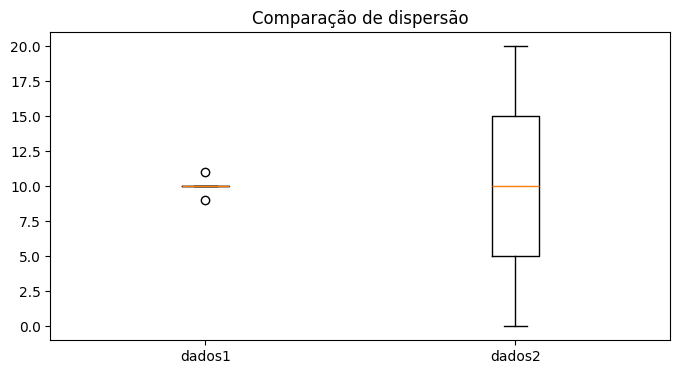

In [1]:
# Exemplo opcional de visualização
import matplotlib.pyplot as plt

dados1 = [9, 10, 10, 10, 11]
dados2 = [0, 5, 10, 15, 20]

plt.figure(figsize=(8,4))
plt.boxplot([dados1, dados2], labels=["dados1", "dados2"])
plt.title("Comparação de dispersão")
plt.show()

In [6]:
media = np.mean(dados1), np.mean(dados2)
desvio = np.std(dados1), np.std(dados2)
variancia = np.var(dados1), np.var(dados2)
media, desvio, variancia

((np.float64(10.0), np.float64(10.0)),
 (np.float64(0.6324555320336759), np.float64(7.0710678118654755)),
 (np.float64(0.4), np.float64(50.0)))

# Desafio final

Uma escola quer analisar o desempenho de duas turmas.

### Turma A
[7, 8, 8, 8, 9, 8, 8]

### Turma B
[2, 5, 8, 8, 11, 14, 8]

## Tarefas
1. Calcule a média das duas turmas
2. Calcule a variância das duas turmas
3. Calcule o desvio padrão das duas turmas
4. Compare os resultados
5. Diga qual turma é mais homogênea
Resposta:
 a turma A é mais homogenia pois, a variancia é menor portanto a dispersao é pquena.

6. Explique por que a média sozinha não resolve essa comparação
Resposta:
A media sozinha nao ressolve pois mesmo as medias sendo iguais a variancia e o desvio padrao podem ser bem diferentes principalmente se tiver outlier.

7. Relacione sua resposta com a ideia de estabilidade de dados em IA
Resposta:
A estabilidade dos dados dependem do quão dispersos e distante da media eles estao.

In [9]:
turma_A = [7, 8, 8, 8, 9, 8, 8]
turma_B = [2, 5, 8, 8, 11, 14, 8]

{
    "media_A": np.mean(turma_A),
    "variancia_A": np.var(turma_A),
    "desvio_A": np.std(turma_A),
    "media_B": np.mean(turma_B),
    "variancia_B": np.var(turma_B),
    "desvio_B": np.std(turma_B),
}

{'media_A': np.float64(8.0),
 'variancia_A': np.float64(0.2857142857142857),
 'desvio_A': np.float64(0.5345224838248488),
 'media_B': np.float64(8.0),
 'variancia_B': np.float64(12.857142857142858),
 'desvio_B': np.float64(3.585685828003181)}

# Gabarito curto – ideias principais

- média semelhante não implica comportamento semelhante
- variância e desvio padrão medem dispersão
- desvio padrão zero significa ausência de variação
- outliers aumentam a dispersão
- em IA, alta dispersão pode indicar:
  - dados heterogêneos
  - presença de anomalias
  - necessidade de padronização

# Fechamento

Nesta aula, estudamos:

- dispersão
- variância
- desvio padrão
- comparação entre conjuntos
- sensibilidade a outliers
- relação com análise de dados e IA

Esses conceitos são fundamentais para interpretar dados com mais profundidade.

A partir daqui, você já consegue responder não só **onde os dados estão**, mas também **o quanto eles variam**.